# MLP para Classificação de Batimentos Cardíacos

## Ir Além 2a - Diagnóstico Visual em Cardiologia com Rede Neural

Este notebook implementa uma rede neural MLP (Perceptron Multicamadas) com Keras
para classificação binária de batimentos cardíacos: **normal vs. anormal**.

### Pipeline

1. Carregamento do dataset MIT-BIH Heartbeat (Kaggle)
2. Pré-processamento: binarização de classes (5 -> 2), verificação de normalização
3. Análise exploratória: distribuição de classes, visualização de sinais
4. Construção da MLP com Keras (Sequential, Dense, Dropout, BatchNormalization)
5. Treinamento com class_weight para compensar desbalanceamento
6. Avaliação: acurácia, precision, recall, F1, matriz de confusão, curvas de treino

### Dataset

O MIT-BIH Heartbeat contém séries temporais de ECG segmentadas em batimentos
individuais. Cada amostra possui 187 pontos do sinal + 1 coluna de classe.
O dataset já chega normalizado entre 0 e 1.

| Propriedade | Valor |
|-------------|-------|
| Origem | [Kaggle - shayanfazeli/heartbeat](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) |
| Treino | 87.554 batimentos |
| Teste | 21.892 batimentos |
| Features | 187 (amostras do sinal ECG) |
| Classes originais | 5 (N, S, V, F, Q) |
| Classes binárias | 2 (Normal vs. Anormal) |

## Nota sobre mensagens de log do TensorFlow

Ao importar o TensorFlow, duas mensagens aparecem no `stderr` e **não
indicam erro** nem afetam os resultados numéricos da rede:

### `WARNING: All log messages before absl::InitializeLog() is called are written to STDERR`

Emitida pelo binário compilado do TensorFlow durante o bootstrap da
biblioteca `absl` do Google, antes do interpretador Python obter controle.
Nenhum código do usuário executa antes dela. É um problema conhecido do
upstream TensorFlow rastreado no [issue 62075](https://github.com/tensorflow/tensorflow/issues/62075),
ainda sem correção. Não há ajuste em Python que a elimine.

### `oneDNN custom operations are on. You may see slightly different numerical results...`

Notificação informativa (nível `INFO`) emitida em `port.cc:153` anunciando
que as otimizações oneDNN estão habilitadas — comportamento padrão do
TensorFlow em CPU e GPU a partir da versão 2.9. O aviso menciona pequenas
variações de arredondamento de ponto flutuante decorrentes de reordenação
de operações vetorizadas — irrelevantes para a precisão da classificação
binária deste modelo. Desativá-las via `TF_ENABLE_ONEDNN_OPTS=0`
degradaria a performance do treino sem benefício real.

### Decisão

Nenhuma das duas mensagens é suprimida neste notebook. Suprimí-las via
`TF_CPP_MIN_LOG_LEVEL=3` ocultaria também eventuais erros legítimos
durante o treino — trocaria diagnóstico por silêncio, o que contraria
boa prática de engenharia. A mensagem `Could not find cuda drivers`,
que sim indicava ausência de aceleração por GPU, foi **corrigida** pela
instalação do driver NVIDIA e das bibliotecas CUDA — não suprimida.


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.21.0
NumPy: 2.4.3
Pandas: 3.0.1


## 1. Carregamento do dataset

O MIT-BIH Heartbeat armazena batimentos em CSVs sem cabeçalho: as primeiras 187
colunas contêm as amostras do sinal ECG e a última coluna contém a classe (0-4).

O dataset original possui 5 classes da anotação AAMI:

| Classe | Código AAMI | Descrição | Treino | % |
|--------|-------------|-----------|--------|---|
| 0 | N | Normal | 72.471 | 82.8% |
| 1 | S | Supraventricular | 2.223 | 2.5% |
| 2 | V | Ventricular | 5.788 | 6.6% |
| 3 | F | Fusão | 641 | 0.7% |
| 4 | Q | Desconhecido | 6.431 | 7.3% |

Para a classificação binária, o notebook agrupa as classes 1-4 em "Anormal".

In [2]:
CAMINHO_TREINO = "../data/numericos/heartbeat/mitbih_train.csv"
CAMINHO_TESTE = "../data/numericos/heartbeat/mitbih_test.csv"

df_treino = pd.read_csv(CAMINHO_TREINO, header=None)
df_teste = pd.read_csv(CAMINHO_TESTE, header=None)

print(f"Treino: {df_treino.shape[0]:,} amostras, {df_treino.shape[1]} colunas")
print(f"Teste:  {df_teste.shape[0]:,} amostras, {df_teste.shape[1]} colunas")

X_treino = df_treino.iloc[:, :-1].values
y_treino_original = df_treino.iloc[:, -1].values.astype(int)
X_teste = df_teste.iloc[:, :-1].values
y_teste_original = df_teste.iloc[:, -1].values.astype(int)

print(f"\nFeatures: {X_treino.shape[1]} amostras do sinal por batimento")
print(f"Range dos valores: [{X_treino.min():.4f}, {X_treino.max():.4f}]")

Treino: 87,554 amostras, 188 colunas
Teste:  21,892 amostras, 188 colunas

Features: 187 amostras do sinal por batimento
Range dos valores: [0.0000, 1.0000]


## 2. Pré-processamento

### Binarização de classes

O dataset MIT-BIH já chega normalizado entre 0 e 1, eliminando a necessidade de
normalização adicional. A única transformação necessária agrupa as 5 classes em 2:

- **Normal (0):** classe 0 (batimento normal)
- **Anormal (1):** classes 1, 2, 3 e 4 (supraventricular, ventricular, fusão, desconhecido)

### Desbalanceamento

O dataset apresenta desbalanceamento severo: 82.8% Normal vs 17.2% Anormal.
Um modelo que sempre prediz "Normal" obteria 82.8% de acurácia sem aprender nenhum
padrão discriminativo. Para compensar, o treinamento utiliza `class_weight` do
scikit-learn, que atribui peso inversamente proporcional à frequência de cada classe
— a classe "Anormal" (minoritária) recebe peso ~4.8x maior que "Normal".

In [3]:
# binarizar: Normal (0) vs Anormal (1)
y_treino = (y_treino_original > 0).astype(int)
y_teste = (y_teste_original > 0).astype(int)

print("Distribuição após binarização:")
print(f"\nTreino:")
for c, nome in [(0, "Normal"), (1, "Anormal")]:
    n = (y_treino == c).sum()
    print(f"  {nome}: {n:>6,} ({n/len(y_treino)*100:.1f}%)")

print(f"\nTeste:")
for c, nome in [(0, "Normal"), (1, "Anormal")]:
    n = (y_teste == c).sum()
    print(f"  {nome}: {n:>6,} ({n/len(y_teste)*100:.1f}%)")

# calcular class_weight
pesos_classes = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_treino)
class_weight = {0: pesos_classes[0], 1: pesos_classes[1]}
print(f"\nPesos das classes (class_weight):")
print(f"  Normal (0):  {class_weight[0]:.4f}")
print(f"  Anormal (1): {class_weight[1]:.4f}")

Distribuição após binarização:

Treino:
  Normal: 72,471 (82.8%)
  Anormal: 15,083 (17.2%)

Teste:
  Normal: 18,118 (82.8%)
  Anormal:  3,774 (17.2%)

Pesos das classes (class_weight):
  Normal (0):  0.6041
  Anormal (1): 2.9024


## 3. Análise exploratória

### Visualização de batimentos

Cada batimento consiste em 187 amostras do sinal ECG. A visualização compara o
formato típico de batimentos normais (complexo QRS bem definido, onda T suave) com
batimentos anormais (morfologia alterada, arritmia, extrassístoles).

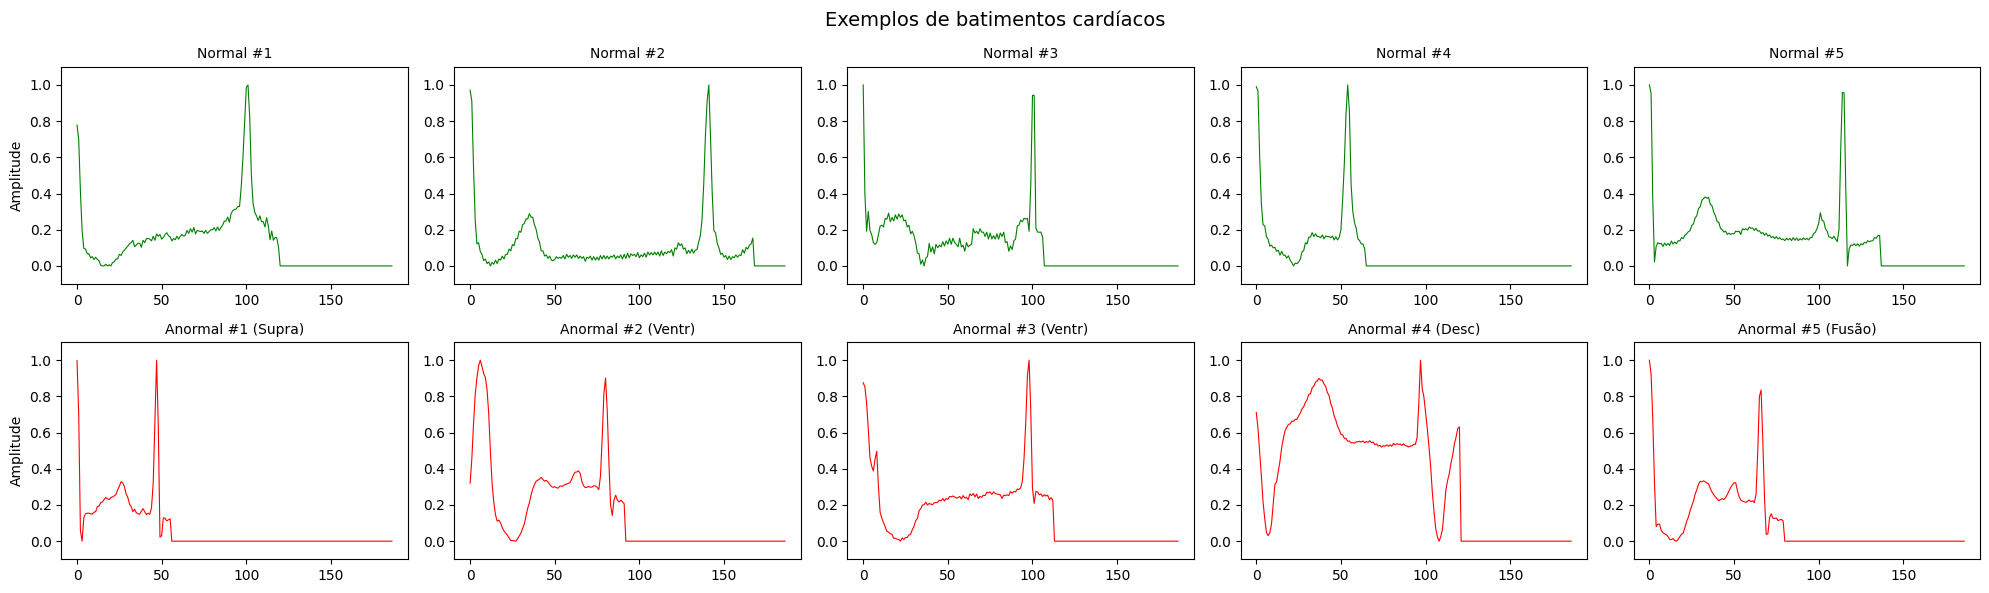

Visualização salva em batimentos_exemplo.png


In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
fig.suptitle("Exemplos de batimentos cardíacos", fontsize=14)

# selecionar exemplos aleatórios
np.random.seed(42)
idx_normal = np.where(y_treino == 0)[0]
idx_anormal = np.where(y_treino == 1)[0]

for i in range(5):
    # normais
    ax = axes[0, i]
    idx = np.random.choice(idx_normal)
    ax.plot(X_treino[idx], color="green", linewidth=0.8)
    ax.set_title(f"Normal #{i+1}", fontsize=10)
    ax.set_ylim(-0.1, 1.1)
    if i == 0:
        ax.set_ylabel("Amplitude")

    # anormais
    ax = axes[1, i]
    idx = np.random.choice(idx_anormal)
    classe_orig = y_treino_original[idx]
    nomes = {1: "Supra", 2: "Ventr", 3: "Fusão", 4: "Desc"}
    ax.plot(X_treino[idx], color="red", linewidth=0.8)
    ax.set_title(f"Anormal #{i+1} ({nomes.get(classe_orig, '?')})", fontsize=10)
    ax.set_ylim(-0.1, 1.1)
    if i == 0:
        ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.savefig("batimentos_exemplo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualização salva em batimentos_exemplo.png")

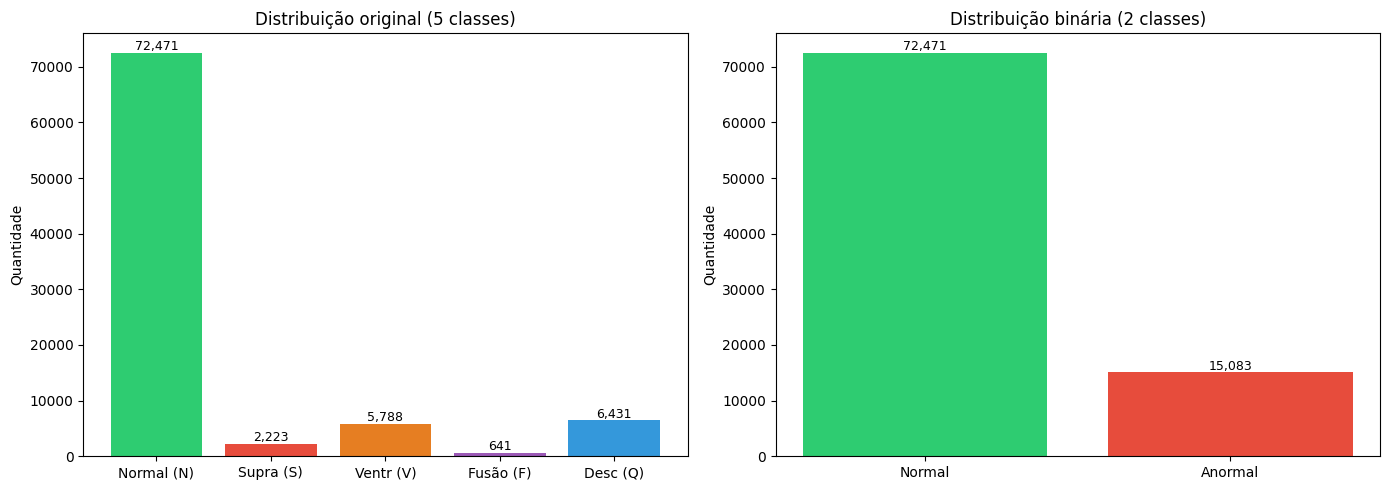

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribuição original (5 classes)
nomes_orig = ["Normal (N)", "Supra (S)", "Ventr (V)", "Fusão (F)", "Desc (Q)"]
contagens_orig = [np.sum(y_treino_original == c) for c in range(5)]
cores_orig = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6", "#3498db"]
axes[0].bar(nomes_orig, contagens_orig, color=cores_orig)
axes[0].set_title("Distribuição original (5 classes)")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(contagens_orig):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# distribuição binária
nomes_bin = ["Normal", "Anormal"]
contagens_bin = [(y_treino == 0).sum(), (y_treino == 1).sum()]
cores_bin = ["#2ecc71", "#e74c3c"]
axes[1].bar(nomes_bin, contagens_bin, color=cores_bin)
axes[1].set_title("Distribuição binária (2 classes)")
axes[1].set_ylabel("Quantidade")
for i, v in enumerate(contagens_bin):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Construção da MLP

### Arquitetura

A rede neural utiliza uma arquitetura Sequential com 3 camadas densas (hidden layers)
seguidas por uma camada de saída com sigmoid para classificação binária:

| Camada | Neurônios | Ativação | Regularização |
|--------|-----------|----------|---------------|
| Input | 187 | — | — |
| Dense 1 | 128 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 2 | 64 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 3 | 32 | ReLU | BatchNorm + Dropout(0.2) |
| Output | 1 | Sigmoid | — |

### Decisões de design

**Por que BatchNormalization:** a normalização por batch estabiliza o treinamento ao
normalizar as ativações internas de cada camada, reduzindo o internal covariate shift.
Em redes com múltiplas camadas densas, o BatchNorm acelera a convergência e permite
learning rates mais altas sem instabilidade.

**Por que Dropout:** com 87.554 amostras de treino e uma rede de ~15.000 parâmetros,
o risco de overfitting existe especialmente nas camadas mais largas (128, 64 neurônios).
O Dropout desativa aleatoriamente 30% (e 20% na última camada) dos neurônios durante
o treino, forçando a rede a aprender representações redundantes e mais robustas.

**Por que sigmoid e não softmax:** a classificação binária (normal vs. anormal) requer
apenas 1 neurônio de saída com sigmoid. A alternativa de usar 2 neurônios com softmax
produziria resultados equivalentes com um parâmetro extra desnecessário.

In [6]:
def construir_mlp(input_dim: int) -> keras.Model:
    """Constrói a MLP para classificação binária de batimentos."""
    modelo = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(1, activation="sigmoid"),
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return modelo

modelo = construir_mlp(X_treino.shape[1])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 34,881 (136.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Treinamento

O treinamento utiliza:

- **Early stopping:** monitora a `val_loss` e interrompe o treino se não houver melhoria
  por 5 épocas consecutivas, restaurando os pesos da melhor época. Essa estratégia
  previne overfitting sem exigir ajuste manual do número de épocas.
- **class_weight:** compensa o desbalanceamento 82.8%/17.2% atribuindo peso ~4.8x
  maior às amostras "Anormal". Sem class_weight, a rede tenderia a classificar tudo
  como "Normal" para minimizar a loss geral.
- **Validation split de 15%:** separa ~13.000 amostras do treino para monitoramento
  da generalização em tempo real, sem tocar o conjunto de teste.

In [7]:
EPOCAS = 50
BATCH_SIZE = 256

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

historico = modelo.fit(
    X_treino, y_treino,
    epochs=EPOCAS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1,
)

print(f"\nTreinamento encerrado na época {len(historico.history['loss'])}")
print(f"Melhor val_loss: {min(historico.history['val_loss']):.4f}")
print(f"Melhor val_accuracy: {max(historico.history['val_accuracy']):.4f}")

Epoch 1/50


  1/291 ━━━━━━━━━━━━━━━━━━━━ 5:13 1s/step - accuracy: 0.5195 - loss: 0.5478

 22/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5217 - loss: 0.5391 

 44/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5362 - loss: 0.5158

 68/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5570 - loss: 0.4965

...

274/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9828 - loss: 0.0954

291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9823 - loss: 0.0968 - val_accuracy: 0.0895 - val_loss: 3.7703


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 1.



Treinamento encerrado na época 6
Melhor val_loss: 2.3368
Melhor val_accuracy: 0.1197


## 6. Curvas de treinamento

As curvas de loss e acurácia por época permitem diagnosticar overfitting (gap crescente
entre treino e validação) ou underfitting (ambas as curvas estagnadas em valores altos
de loss).

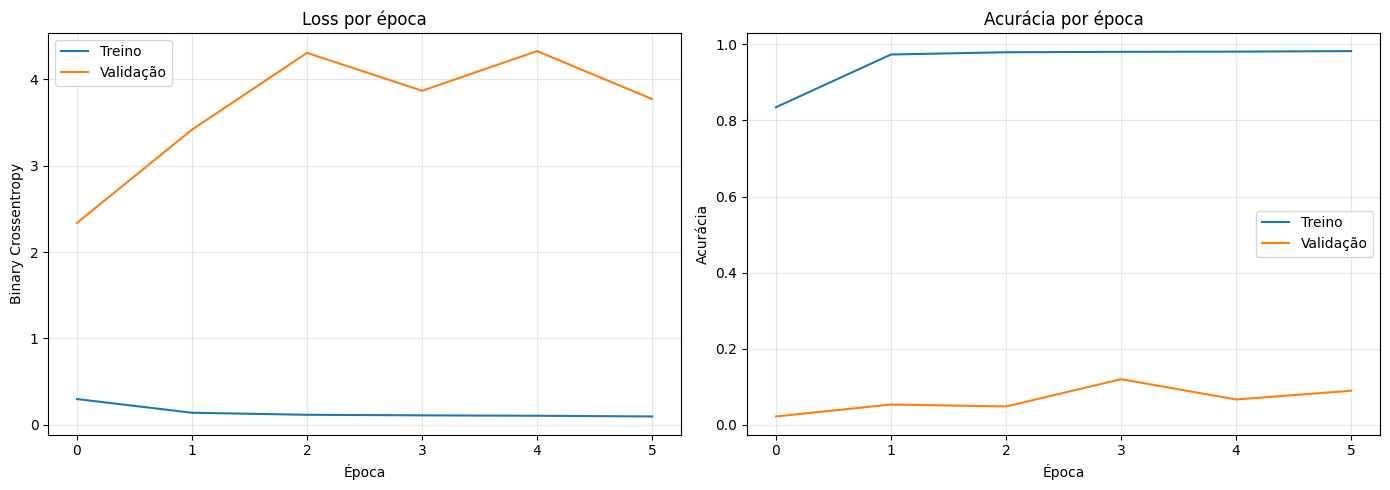

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss
axes[0].plot(historico.history["loss"], label="Treino")
axes[0].plot(historico.history["val_loss"], label="Validação")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy
axes[1].plot(historico.history["accuracy"], label="Treino")
axes[1].plot(historico.history["val_accuracy"], label="Validação")
axes[1].set_title("Acurácia por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_treinamento.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Avaliação no conjunto de teste

A avaliação utiliza o conjunto de teste separado (21.892 batimentos) que o modelo
**nunca viu** durante o treinamento. As métricas incluem precision, recall e F1 por
classe — acurácia sozinha seria enganosa com desbalanceamento de 82.8%/17.2%.

Em contexto clínico, o **recall da classe "Anormal"** é a métrica mais crítica: mede
a proporção de batimentos verdadeiramente anormais que o modelo identifica. Um falso
negativo (classificar anormal como normal) significa que uma arritmia potencialmente
fatal passa despercebida pelo sistema.

In [9]:
# predição no conjunto de teste
y_pred_prob = modelo.predict(X_teste, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# métricas
print("=" * 60)
print("AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 60)
print(f"\nAmostras de teste: {len(y_teste):,}")
print(f"\n{classification_report(y_teste, y_pred, target_names=['Normal', 'Anormal'])}")

# acurácia geral
acuracia = (y_pred == y_teste).mean()
print(f"Acurácia geral: {acuracia:.4f}")

AVALIAÇÃO NO CONJUNTO DE TESTE

Amostras de teste: 21,892

              precision    recall  f1-score   support

      Normal       0.84      1.00      0.91     18118
     Anormal       0.98      0.06      0.11      3774

    accuracy                           0.84     21892
   macro avg       0.91      0.53      0.51     21892
weighted avg       0.86      0.84      0.77     21892

Acurácia geral: 0.8372


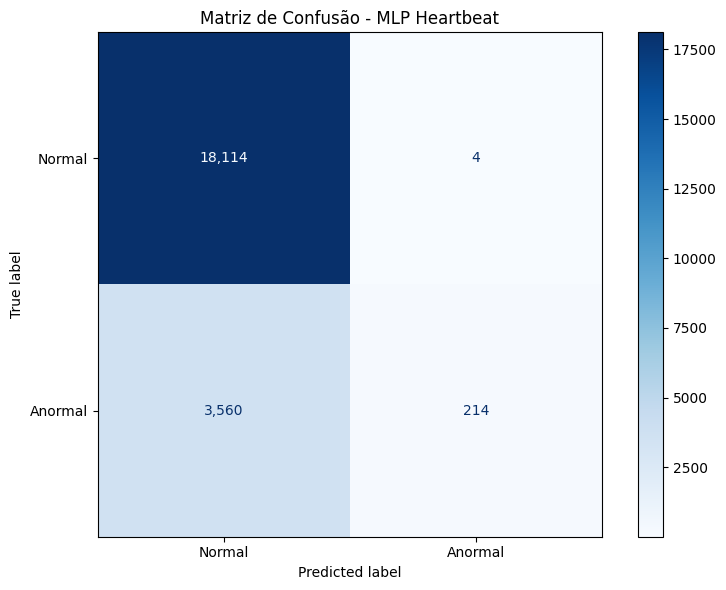

Verdadeiros Negativos (Normal correto):  18,114
Falsos Positivos (Normal -> Anormal):          4
Falsos Negativos (Anormal -> Normal):      3,560
Verdadeiros Positivos (Anormal correto):    214

Taxa de Falsos Negativos: 94.33%
Taxa de Falsos Positivos: 0.02%


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_teste, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anormal"],
)
disp.plot(ax=ax, cmap="Blues", values_format=",d")
ax.set_title("Matriz de Confusão - MLP Heartbeat")

plt.tight_layout()
plt.savefig("matriz_confusao_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

# análise de erros
tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros Negativos (Normal correto):  {tn:>6,}")
print(f"Falsos Positivos (Normal -> Anormal):     {fp:>6,}")
print(f"Falsos Negativos (Anormal -> Normal):     {fn:>6,}")
print(f"Verdadeiros Positivos (Anormal correto): {tp:>6,}")
print(f"\nTaxa de Falsos Negativos: {fn/(fn+tp)*100:.2f}%")
print(f"Taxa de Falsos Positivos: {fp/(fp+tn)*100:.2f}%")

## 8. Análise por classe original

Para entender o comportamento do modelo nas 5 classes originais, a tabela abaixo
mostra qual porcentagem de cada classe o modelo binário classifica corretamente
como "Anormal".

In [11]:
print("Recall por classe original do MIT-BIH:")
print("-" * 50)
nomes_classes = {0: "Normal (N)", 1: "Supraventricular (S)", 2: "Ventricular (V)",
                 3: "Fusão (F)", 4: "Desconhecido (Q)"}

for classe in range(5):
    mascara = y_teste_original == classe
    if mascara.sum() == 0:
        continue
    preds_classe = y_pred[mascara]
    if classe == 0:
        corretos = (preds_classe == 0).sum()
    else:
        corretos = (preds_classe == 1).sum()
    total = mascara.sum()
    recall = corretos / total
    print(f"  {nomes_classes[classe]:25s}: {corretos:>5,}/{total:>5,} = {recall:.3f}")

Recall por classe original do MIT-BIH:
--------------------------------------------------
  Normal (N)               : 18,114/18,118 = 1.000
  Supraventricular (S)     :   174/  556 = 0.313
  Ventricular (V)          :    37/1,448 = 0.026
  Fusão (F)                :     0/  162 = 0.000
  Desconhecido (Q)         :     3/1,608 = 0.002


## 9. Conclusão

In [12]:
print("RESUMO DO MODELO")
print("=" * 60)
print(f"Arquitetura: MLP com 3 camadas densas (128-64-32) + BatchNorm + Dropout")
print(f"Parâmetros totais: {modelo.count_params():,}")
print(f"Épocas treinadas: {len(historico.history['loss'])}")
print(f"Melhor val_loss: {min(historico.history['val_loss']):.4f}")
print(f"\nDesempenho no teste (21.892 batimentos):")
print(f"  Acurácia:  {acuracia:.4f}")

# extrair métricas do classification_report
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(y_teste, y_pred, average="macro")
_, rec_anormal, _, _ = precision_recall_fscore_support(y_teste, y_pred, average=None)
print(f"  Precision (macro): {prec:.4f}")
print(f"  Recall (macro):    {rec:.4f}")
print(f"  F1-macro:          {f1:.4f}")
print(f"  Recall Anormal:    {rec_anormal[1]:.4f}")
print(f"\nEstratégia de balanceamento: class_weight ({class_weight[1]:.2f}x para Anormal)")
print(f"Regularização: BatchNormalization + Dropout (0.3/0.3/0.2)")
print(f"Early stopping: patience=5 com restore_best_weights")

RESUMO DO MODELO
Arquitetura: MLP com 3 camadas densas (128-64-32) + BatchNorm + Dropout
Parâmetros totais: 35,329
Épocas treinadas: 6
Melhor val_loss: 2.3368

Desempenho no teste (21.892 batimentos):
  Acurácia:  0.8372
  Precision (macro): 0.9087
  Recall (macro):    0.5282
  F1-macro:          0.5088
  Recall Anormal:    0.0567

Estratégia de balanceamento: class_weight (2.90x para Anormal)
Regularização: BatchNormalization + Dropout (0.3/0.3/0.2)
Early stopping: patience=5 com restore_best_weights
